## 3. Exercise 1: Implement the Hungarian Algorithm for Graph Matching


In [1]:
import numpy as np
from PIL import Image
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay 
from scipy.optimize import linear_sum_assignment
import os

def load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2):
    """
    Carga y preprocesa pares de imágenes y sus keypoints
    """


def delaunay_triangulation(kpt):
    """
    Generate adjacency matrix based on Delaunay triangulation
    """
    return A



def simple_spatial_matching(kpts1, kpts2):
    """
    Realiza matching entre puntos usando distancia euclidiana y algoritmo húngaro optimizado
    
    Args:
        kpts1: Array de keypoints del primer grafo (2xN)
        kpts2: Array de keypoints del segundo grafo (2xN)
    
    Returns:
        matching: Matriz binaria donde matching[i,j]=1 indica correspondencia entre puntos
    Hints:
        - Primero deberás crear una matriz de costes basada en distancias euclidianas,
        cuyo tamaño será (n1, n2) donde n1 y n2 son el número de keypoints en cada grafo.
        - Seguidamente, deberás rellenar dicha matriz con las distancias euclidianas entre
        los keypoints de ambos grafos.
        - A continuación, deberás aplicar el algoritmo húngaro usando la función linear_sum_assignment, que recibe la matriz de costes y devuelve los índices de los puntos emparejados.
        - Finalmente, deberás crear una matriz de matching a partir de los índices obtenidos.

    """
    
    n1, n2 = kpts1.shape[1], kpts2.shape[1]
    cost_matrix= np.zeros((n1,n2))
    for i in range(n1):
        for j in range(n2):
            cost_matrix[i,j] = np.sqrt(np.sum((kpts1[:,i] - kpts2[:,j])**2))
    
    row_index,col_index = linear_sum_assignment(cost_matrix)
    # Pasamos de un array de 2XE a un array de NxN
    matching = np.zeros((n1,n2))
    matching[row_index,col_index] = 1
    return matching

def visualize_matching_full(img1, img2, kpts1, kpts2, adj_matrix1, adj_matrix2, matching):
    """
    Visualiza el matching completo entre dos grafos
    """
    
    
    # Graficar una imagen al lado de otra
    plt.figure(figsize=(15,8))
    # SI ya estan redimensionadas no haria falta (el max), simplemente se haria ancho = img1.shape
    ancho = max (img1.size[0],img2.size[0])
    alto = max (img1.size[1],img2.size[1])
    composicion = Image.new('RGB', (ancho*2, alto))
    composicion.paste(img1, (0,0))
    composicion.paste(img2, (ancho,0))
    plt.imshow(composicion)
    
    
    # Graficar las coordenadas (keypoints)
    plt.scatter(kpts1[0], kpts1[1], c='w', edgecolors='k', s=100)
    plt.scatter(kpts2[0] + ancho, kpts2[1], c='w', edgecolors='k', s=100)
    # Graficamoslas arsitas del matching
    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] > 0:
                color = 'g' if i==j else 'r'
                plt.plot([kpts1[0,i], kpts2[0,j] + ancho],
                         [kpts1[1,i], kpts2[1,j]],
                         color = color, linewidth=2)

    

    
    

### Cargamos las imágenes

In [2]:
def load_and_preprocess_images2():
    """
    Carga y preprocesa pares de imágenes y sus keypoints
    """
    # Definimos tamaño objeto
    obj_resize = (256,256)
    category = 'Duck'
    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category
    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs = []
    kpts_list = []
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)
    pngs = sorted(pngs)
    mats = sorted(mats)
    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list.append(kpts)
        imgs.append(img)
    # Devolvemos los valores para poder usar la otra función

        # Definimos tamaño objeto
    obj_resize = (256,256)
    category = 'Duck'
    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category
    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs2 = []
    kpts_list2 = []
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)
    pngs = sorted(pngs)
    mats = sorted(mats)
    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list2.append(kpts)
        imgs2.append(img)

    return imgs[0], imgs2[1], kpts_list[0], kpts_list2[1]

### Matriz de adyacencia

In [3]:
import numpy as np
from scipy.spatial import Delaunay

def delaunay_triangulation(kpts):
    """
    Generate adjacency matrix based on Delaunay triangulation
    """
    pts = kpts.T
    tri = Delaunay(pts)
    N = pts.shape[0]
    A = np.zeros((N, N), dtype=int)

    for simplex in tri.simplices:
        a, b, c = simplex
        # Poner 1 en la matriz para cada arista
        A[a, b] = 1
        A[b, a] = 1
        A[b, c] = 1
        A[c, b] = 1
        A[a, c] = 1
        A[c, a] = 1

    return A

### Hacemos el matching

In [4]:
def simple_spatial_matching(kpts1, kpts2):
    """
    Realiza matching entre puntos usando distancia euclidiana y algoritmo húngaro optimizado
    
    Args:
        kpts1: Array de keypoints del primer grafo (2xN)
        kpts2: Array de keypoints del segundo grafo (2xN)
    
    Returns:
        matching: Matriz binaria donde matching[i,j]=1 indica correspondencia entre puntos
    Hints:
        - Primero deberás crear una matriz de costes basada en distancias euclidianas,
        cuyo tamaño será (n1, n2) donde n1 y n2 son el número de keypoints en cada grafo.
        - Seguidamente, deberás rellenar dicha matriz con las distancias euclidianas entre
        los keypoints de ambos grafos.
        - A continuación, deberás aplicar el algoritmo húngaro usando la función linear_sum_assignment, que recibe la matriz de costes y devuelve los índices de los puntos emparejados.
        - Finalmente, deberás crear una matriz de matching a partir de los índices obtenidos.

    """
    
    n1, n2 = kpts1.shape[1], kpts2.shape[1]
    cost_matrix= np.zeros((n1,n2))
    for i in range(n1):
        for j in range(n2):
            cost_matrix[i,j] = np.sqrt(np.sum((kpts1[:,i] - kpts2[:,j])**2))
    
    row_index,col_index = linear_sum_assignment(cost_matrix)
    # Pasamos de un array de 2XE a un array de NxN
    matching = np.zeros((n1,n2))
    matching[row_index,col_index] = 1
    return matching

### Visualizamos las imágenes

In [5]:
def visualize_matching_full(img1, img2, kpts1, kpts2, adj_matrix1, adj_matrix2, matching):
    """
    Visualiza el matching completo entre dos grafos
    """
    
    
    # Graficar una imagen al lado de otra
    plt.figure(figsize=(15,8))
    # SI ya estan redimensionadas no haria falta (el max), simplemente se haria ancho = img1.shape
    ancho = max (img1.size[0],img2.size[0])
    alto = max (img1.size[1],img2.size[1])
    composicion = Image.new('RGB', (ancho*2, alto))
    composicion.paste(img1, (0,0))
    composicion.paste(img2, (ancho,0))
    plt.imshow(composicion)
    
    
    # Graficar las coordenadas (keypoints)
    plt.scatter(kpts1[0], kpts1[1], c='w', edgecolors='k', s=100)
    plt.scatter(kpts2[0] + ancho, kpts2[1], c='w', edgecolors='k', s=100)
    # Graficamoslas arsitas del matching
    matching = np.array(matching)
    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] > 0:
                color = 'g' if i==j else 'r'
                plt.plot([kpts1[0,i], kpts2[0,j] + ancho],
                         [kpts1[1,i], kpts2[1,j]],
                         color = color, linewidth=2)

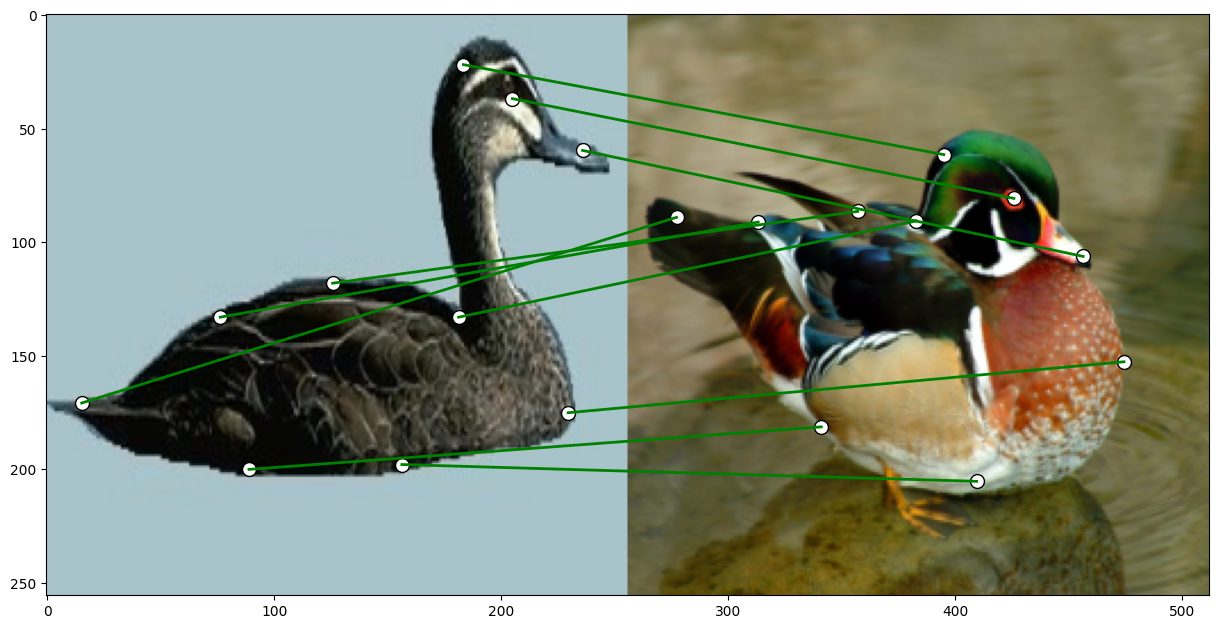

In [6]:
#Cargamos las dos imágenes
imgs1,imgs2,kpts1,kpts2 = load_and_preprocess_images2()

#Matriz de adyacencia
A = delaunay_triangulation(kpts1)
A2 = delaunay_triangulation(kpts2)

#Matching
matching = simple_spatial_matching(kpts1,kpts2)

#Visualizamos las imágenes
visualize_matching_full(imgs1,imgs2,kpts1,kpts2,A,A2,matching)